# Notebook AI Engineer - Deep Learning Career Aspiration Prediction

Notebook ini dibuat untuk bagian **AI Engineer** berdasarkan pekerjaan Data Scientist yang sudah melakukan gathering data dan EDA pada proyek rekomendasi jurusan/karier siswa.

Notebook ini memenuhi ketentuan AI Engineer:

1. Membangun model Deep Learning menggunakan **TensorFlow Functional API**.
2. Mengimplementasikan komponen kustom lanjutan, yaitu:
   - **Custom Layer**: `FeatureInteractionLayer`
   - **Custom Callback**: `TargetAccuracyCallback`
3. Menyimpan model terlatih dalam format **`.keras`**.
4. Mengekspor model ke format **SavedModel**.
5. Membuat kode sederhana untuk **inference model**.

Target prediksi yang digunakan adalah **`career_aspiration`**.

## 1. Install Library

Jalankan cell ini terlebih dahulu di Google Colab.

In [1]:
!pip -q install pandas numpy scikit-learn tensorflow matplotlib joblib

## 2. Import Library

In [2]:
import os
import json
import shutil
import joblib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, Model, Input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Load Dataset dari Hasil Data Scientist

Notebook ini mencari file dataset dengan urutan prioritas berikut:

1. `df_ready_for_model.csv`
2. `scores_clean.csv`
3. `main_data.csv`
4. `student-scores-6k.csv`

Jika file belum ada di Colab, notebook akan meminta kamu upload file CSV hasil pekerjaan Data Scientist.

In [3]:
CANDIDATE_FILES = [
    "df_ready_for_model.csv",
    "scores_clean.csv",
    "main_data.csv",
    "student-scores-6k.csv"
]

def find_existing_dataset(candidate_files):
    for path in candidate_files:
        if os.path.exists(path):
            return path
    return None

DATA_PATH = find_existing_dataset(CANDIDATE_FILES)

if DATA_PATH is None:
    print("Dataset belum ditemukan di session Colab.")
    print("Silakan upload salah satu file berikut:")
    for file_name in CANDIDATE_FILES:
        print("-", file_name)
    uploaded = files.upload()
    DATA_PATH = find_existing_dataset(list(uploaded.keys()))

if DATA_PATH is None:
    raise FileNotFoundError("Dataset CSV belum ditemukan. Upload file dataset terlebih dahulu.")

print("Dataset yang digunakan:", DATA_PATH)
df_raw = pd.read_csv(DATA_PATH)
print("Shape awal:", df_raw.shape)
df_raw.head()

Dataset yang digunakan: df_ready_for_model.csv
Shape awal: (6000, 23)


,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,...,major_group,average_score,performance_category,sains_score,sosial_score,bahasa_score,gender_Female,gender_Male,career_encoded,major_group_encoded
0,Male,0,0.3,0,0.54,Lawyer,0.425532,0.62,0.86,0.94,...,Sosial & Hukum,0.617838,Sedang,0.625731,0.651685,0.612245,0,1,9,3
1,Female,0,0.2,0,0.94,Doctor,0.787234,0.72,0.92,1.00,...,Sains & Kesehatan,0.872703,Tinggi,0.918129,0.741573,0.775510,1,0,6,1
2,Female,0,0.9,1,0.26,Government Officer,0.595745,0.94,0.90,0.92,...,Sosial & Hukum,0.737568,Tinggi,0.690058,0.910112,0.551020,1,0,8,3
3,Female,0,0.5,0,0.06,Artist,0.382979,0.48,0.76,0.60,...,Seni & Kreatif,0.528919,Sedang,0.637427,0.561798,0.265306,1,0,1,2
4,Male,0,0.5,0,0.20,Social Network Studies,0.659574,0.54,0.30,0.30,...,Sosial & Hukum,0.413243,Rendah,0.438596,0.483146,0.489796,0,1,12,3


## 4. Pemeriksaan Awal Dataset

In [4]:
print("Daftar kolom dataset:")
print(df_raw.columns.tolist())

print("\nInfo dataset:")
df_raw.info()

print("\nJumlah missing value:")
print(df_raw.isnull().sum())

print("\nJumlah duplikasi data:")
print(df_raw.duplicated().sum())

print("\n5 data pertama:")
display(df_raw.head())

Daftar kolom dataset:
['gender', 'part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'career_aspiration', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score', 'major_group', 'average_score', 'performance_category', 'sains_score', 'sosial_score', 'bahasa_score', 'gender_Female', 'gender_Male', 'career_encoded', 'major_group_encoded']

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      6000 non-null   object 
 1   part_time_job               6000 non-null   int64  
 2   absence_days                6000 non-null   float64
 3   extracurricular_activities  6000 non-null   int64  
 4   weekly_self_study_hours     6000 non-null   float64
 5   career_aspiration           6000 n

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,...,major_group,average_score,performance_category,sains_score,sosial_score,bahasa_score,gender_Female,gender_Male,career_encoded,major_group_encoded
0,Male,0,0.3,0,0.54,Lawyer,0.425532,0.62,0.86,0.94,...,Sosial & Hukum,0.617838,Sedang,0.625731,0.651685,0.612245,0,1,9,3
1,Female,0,0.2,0,0.94,Doctor,0.787234,0.72,0.92,1.00,...,Sains & Kesehatan,0.872703,Tinggi,0.918129,0.741573,0.775510,1,0,6,1
2,Female,0,0.9,1,0.26,Government Officer,0.595745,0.94,0.90,0.92,...,Sosial & Hukum,0.737568,Tinggi,0.690058,0.910112,0.551020,1,0,8,3
3,Female,0,0.5,0,0.06,Artist,0.382979,0.48,0.76,0.60,...,Seni & Kreatif,0.528919,Sedang,0.637427,0.561798,0.265306,1,0,1,2
4,Male,0,0.5,0,0.20,Social Network Studies,0.659574,0.54,0.30,0.30,...,Sosial & Hukum,0.413243,Rendah,0.438596,0.483146,0.489796,0,1,12,3


## 5. Preprocessing Ringkas untuk Kebutuhan Model

Bagian ini menjaga notebook tetap bisa berjalan baik ketika input yang digunakan adalah data raw maupun data bersih dari tim Data Scientist.

In [5]:
df = df_raw.copy()

# Standarisasi nama kolom agar konsisten
df.columns = [str(col).strip().lower().replace(" ", "_") for col in df.columns]

TARGET_COL = "career_aspiration"
if TARGET_COL not in df.columns:
    raise ValueError(
        f"Kolom target '{TARGET_COL}' tidak ditemukan. "
        f"Kolom tersedia: {df.columns.tolist()}"
    )

# Hapus kolom identitas jika masih ada
identity_cols = ["id", "first_name", "last_name", "email"]
cols_to_drop = [col for col in identity_cols if col in df.columns]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print("Kolom identitas dihapus:", cols_to_drop)

# Hapus duplikasi
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah duplikasi yang dihapus:", duplicate_count)

# Standarisasi nilai kategorikal
for col in df.select_dtypes(include=["object", "category"]).columns:
    df[col] = df[col].astype(str).str.strip()

# Konversi boolean menjadi 0/1
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

print("Shape setelah cleaning awal:", df.shape)
print("Distribusi target:")
print(df[TARGET_COL].value_counts())
df.head()

Jumlah duplikasi yang dihapus: 4000
Shape setelah cleaning awal: (2000, 23)
Distribusi target:
career_aspiration
Software Engineer         315
Business Owner            309
Social Network Studies    223
Banker                    169
Lawyer                    138
Accountant                126
Doctor                    119
Real Estate Developer      83
Stock Investor             73
Construction Engineer      68
Artist                     67
Game Developer             63
Government Officer         61
Teacher                    59
Designer                   56
Scientist                  39
Writer                     32
Name: count, dtype: int64


,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,...,major_group,average_score,performance_category,sains_score,sosial_score,bahasa_score,gender_female,gender_male,career_encoded,major_group_encoded
0,Male,0,0.3,0,0.54,Lawyer,0.425532,0.62,0.86,0.94,...,Sosial & Hukum,0.617838,Sedang,0.625731,0.651685,0.612245,0,1,9,3
1,Female,0,0.2,0,0.94,Doctor,0.787234,0.72,0.92,1.00,...,Sains & Kesehatan,0.872703,Tinggi,0.918129,0.741573,0.775510,1,0,6,1
2,Female,0,0.9,1,0.26,Government Officer,0.595745,0.94,0.90,0.92,...,Sosial & Hukum,0.737568,Tinggi,0.690058,0.910112,0.551020,1,0,8,3
3,Female,0,0.5,0,0.06,Artist,0.382979,0.48,0.76,0.60,...,Seni & Kreatif,0.528919,Sedang,0.637427,0.561798,0.265306,1,0,1,2
4,Male,0,0.5,0,0.20,Social Network Studies,0.659574,0.54,0.30,0.30,...,Sosial & Hukum,0.413243,Rendah,0.438596,0.483146,0.489796,0,1,12,3


## 6. Feature Engineering Sederhana

Fitur tambahan dibuat berdasarkan konteks data siswa, seperti rata-rata nilai, nilai domain sains, sosial, dan bahasa.

In [6]:
score_cols = [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score"
]
score_cols = [col for col in score_cols if col in df.columns]

print("Kolom nilai yang tersedia:", score_cols)

if len(score_cols) > 0:
    df["average_score"] = df[score_cols].mean(axis=1)

sains_cols = [col for col in ["physics_score", "chemistry_score", "biology_score", "math_score"] if col in df.columns]
sosial_cols = [col for col in ["history_score", "geography_score"] if col in df.columns]

if len(sains_cols) > 0:
    df["sains_score"] = df[sains_cols].mean(axis=1)

if len(sosial_cols) > 0:
    df["sosial_score"] = df[sosial_cols].mean(axis=1)

if "english_score" in df.columns:
    df["bahasa_score"] = df["english_score"]

if "average_score" in df.columns:
    q33 = df["average_score"].quantile(0.33)
    q66 = df["average_score"].quantile(0.66)
    df["performance_category"] = pd.cut(
        df["average_score"],
        bins=[-np.inf, q33, q66, np.inf],
        labels=["Rendah", "Sedang", "Tinggi"]
    ).astype(str)

print("Shape setelah feature engineering:", df.shape)
df.head()

Kolom nilai yang tersedia: ['math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score']
Shape setelah feature engineering: (2000, 23)


,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,...,major_group,average_score,performance_category,sains_score,sosial_score,bahasa_score,gender_female,gender_male,career_encoded,major_group_encoded
0,Male,0,0.3,0,0.54,Lawyer,0.425532,0.62,0.86,0.94,...,Sosial & Hukum,0.650665,Sedang,0.661852,0.6475,0.612245,0,1,9,3
1,Female,0,0.2,0,0.94,Doctor,0.787234,0.72,0.92,1.00,...,Sains & Kesehatan,0.828071,Tinggi,0.887746,0.7350,0.775510,1,0,6,1
2,Female,0,0.9,1,0.26,Government Officer,0.595745,0.94,0.90,0.92,...,Sosial & Hukum,0.744270,Tinggi,0.717217,0.8950,0.551020,1,0,8,3
3,Female,0,0.5,0,0.06,Artist,0.382979,0.48,0.76,0.60,...,Seni & Kreatif,0.566630,Rendah,0.642776,0.5650,0.265306,1,0,1,2
4,Male,0,0.5,0,0.20,Social Network Studies,0.659574,0.54,0.30,0.30,...,Sosial & Hukum,0.482410,Rendah,0.486769,0.4700,0.489796,0,1,12,3


## 7. Encoding Target dan Fitur

Target `career_aspiration` diubah menjadi label numerik. Fitur kategorikal input diubah dengan one-hot encoding.

In [16]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[TARGET_COL].astype(str))
class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

print("Jumlah kelas target:", num_classes)
for idx, label in enumerate(class_names):
    print(idx, ":", label)

# Pisahkan fitur dari target
X_df = df.drop(columns=[TARGET_COL])

# Jika ada kolom target encoded lama, hapus agar tidak terjadi data leakage
possible_leakage_cols = ["career_encoded", "target", "label"]
for col in possible_leakage_cols:
    if col in X_df.columns:
        X_df = X_df.drop(columns=[col])
        print("Kolom leakage dihapus:", col)

# One-hot encoding fitur kategorikal
categorical_cols = X_df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Kolom kategorikal input:", categorical_cols)

X_encoded = pd.get_dummies(X_df, columns=categorical_cols, drop_first=False)

# Pastikan semua fitur numerik
X_encoded = X_encoded.apply(pd.to_numeric, errors="coerce")

# Imputasi missing value menggunakan median
feature_medians = X_encoded.median(numeric_only=True)
X_encoded = X_encoded.fillna(feature_medians)

feature_cols = X_encoded.columns.tolist()
X = X_encoded.astype("float32").values
y = y.astype("int32")

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Jumlah fitur model:", len(feature_cols))

Jumlah kelas target: 6
0 : 0
1 : 1
2 : 2
3 : 3
4 : 4
5 : 5
Kolom leakage dihapus: career_encoded
Kolom kategorikal input: ['gender', 'career_aspiration', 'major_group', 'performance_category']
Shape X: (2000, 45)
Shape y: (2000,)
Jumlah fitur model: 45


## 8. Split Dataset Manual: Train, Validation, dan Test

Dataset dibagi manual menjadi:

- 70% train
- 15% validation
- 15% test

In [17]:
# Cek apakah stratify memungkinkan
unique, counts = np.unique(y, return_counts=True)
min_class_count = counts.min()
use_stratify = min_class_count >= 2

print("Jumlah minimum data per kelas:", min_class_count)
print("Menggunakan stratify:", use_stratify)

stratify_y = y if use_stratify else None

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_y
)

stratify_temp = y_temp if use_stratify else None

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=stratify_temp
)

print("Jumlah data train      :", X_train.shape[0])
print("Jumlah data validation :", X_val.shape[0])
print("Jumlah data test       :", X_test.shape[0])
print("Total data             :", X_train.shape[0] + X_val.shape[0] + X_test.shape[0])

Jumlah minimum data per kelas: 68
Menggunakan stratify: True
Jumlah data train      : 1400
Jumlah data validation : 300
Jumlah data test       : 300
Total data             : 2000


## 9. Custom Layer

`FeatureInteractionLayer` digunakan untuk membentuk representasi non-linear dari fitur siswa. Layer ini menggabungkan fitur asli, fitur kuadrat, dan transformasi log.

In [18]:
@tf.keras.utils.register_keras_serializable()
class FeatureInteractionLayer(layers.Layer):
    def __init__(self, units=64, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = activation
        self.dense = layers.Dense(units, activation=activation)

    def call(self, inputs):
        squared_features = tf.square(inputs)
        log_features = tf.math.log1p(tf.abs(inputs))
        combined_features = tf.concat([inputs, squared_features, log_features], axis=-1)
        return self.dense(combined_features)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "activation": self.activation})
        return config

## 10. Custom Callback

`TargetAccuracyCallback` menghentikan training jika akurasi validasi sudah mencapai target tertentu.

In [19]:
class TargetAccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_accuracy=0.92):
        super().__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get("val_accuracy")

        if val_acc is not None:
            print(" - Custom Callback: val_accuracy = {:.4f}".format(val_acc))

            if val_acc >= self.target_accuracy:
                print(
                    "Target validation accuracy {:.2f} tercapai. Training dihentikan.".format(
                        self.target_accuracy
                    )
                )
                self.model.stop_training = True

## 11. Membangun Model Deep Learning dengan TensorFlow Functional API

In [20]:
input_dim = X_train.shape[1]

normalizer = layers.Normalization(name="feature_normalization")
normalizer.adapt(X_train)

inputs = Input(shape=(input_dim,), name="student_features")

x = normalizer(inputs)

x = FeatureInteractionLayer(
    units=128,
    activation="relu",
    name="custom_feature_interaction"
)(x)

x = layers.Dense(128, activation="relu", name="dense_1")(x)
x = layers.BatchNormalization(name="batch_norm_1")(x)
x = layers.Dropout(0.30, name="dropout_1")(x)

x = layers.Dense(64, activation="relu", name="dense_2")(x)
x = layers.BatchNormalization(name="batch_norm_2")(x)
x = layers.Dropout(0.25, name="dropout_2")(x)

x = layers.Dense(32, activation="relu", name="dense_3")(x)
x = layers.Dropout(0.15, name="dropout_3")(x)

outputs = layers.Dense(num_classes, activation="softmax", name="career_prediction")(x)

model = Model(inputs=inputs, outputs=outputs, name="student_career_recommendation_model")
model.summary()

Model: "student_career_recommendation_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ student_features (InputLayer)   │ (None, 45)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_normalization           │ (None, 45)             │            91 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_feature_interaction      │ (None, 128)            │        17,408 │
│ (FeatureInteractionLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ career_prediction (Dense)       │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,313 (177.01 KB)

 Trainable params: 44,838 (175.15 KB)

 Non-trainable params: 475 (1.86 KB)

## 12. Compile Model

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model berhasil di-compile.")

Model berhasil di-compile.


## 13. Class Weight untuk Menangani Ketidakseimbangan Kelas

In [22]:
classes = np.unique(y_train)

if len(classes) == num_classes:
    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train
    )
    class_weight = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_array)}
else:
    class_weight = None

print("Class weight:")
print(class_weight)

Class weight:
{0: 0.43859649122807015, 1: 2.121212121212121, 2: 2.1604938271604937, 3: 0.6923837784371909, 4: 4.861111111111111, 5: 0.8805031446540881}


## 14. Training Model

In [23]:
os.makedirs("model_output", exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="model_output/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    TargetAccuracyCallback(target_accuracy=0.92)
]

EPOCHS = 100
BATCH_SIZE = 64

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/100
21/22 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2776 - loss: 1.7482
Epoch 1: val_accuracy improved from None to 0.37333, saving model to model_output/best_model.keras

Epoch 1: finished saving model to model_output/best_model.keras
 - Custom Callback: val_accuracy = 0.3733
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.3993 - loss: 1.2523 - val_accuracy: 0.3733 - val_loss: 1.1905 - learning_rate: 0.0010
Epoch 2/100
16/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7225 - loss: 0.5460 
Epoch 2: val_accuracy improved from 0.37333 to 0.90667, saving model to model_output/best_model.keras

Epoch 2: finished saving model to model_output/best_model.keras
 - Custom Callback: val_accuracy = 0.9067
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8321 - loss: 0.4433 - val_accuracy: 0.9067 - val_loss: 0.6463 - learning_rate: 0.0010
Epoch 3/100
15/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9708 - loss: 0.2495 
Epoch 3: val_accuracy improved from 0.90667 to 

## 15. Evaluasi Model

In [24]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy   :", train_acc)
print("Validation Accuracy :", val_acc)
print("Testing Accuracy    :", test_acc)

Training Accuracy   : 0.9992856979370117
Validation Accuracy : 1.0
Testing Accuracy    : 0.996666669845581


## 16. Classification Report dan Confusion Matrix

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       114
           1       1.00      1.00      1.00        24
           2       0.96      1.00      0.98        24
           3       1.00      1.00      1.00        72
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        56

    accuracy                           1.00       300
   macro avg       0.99      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



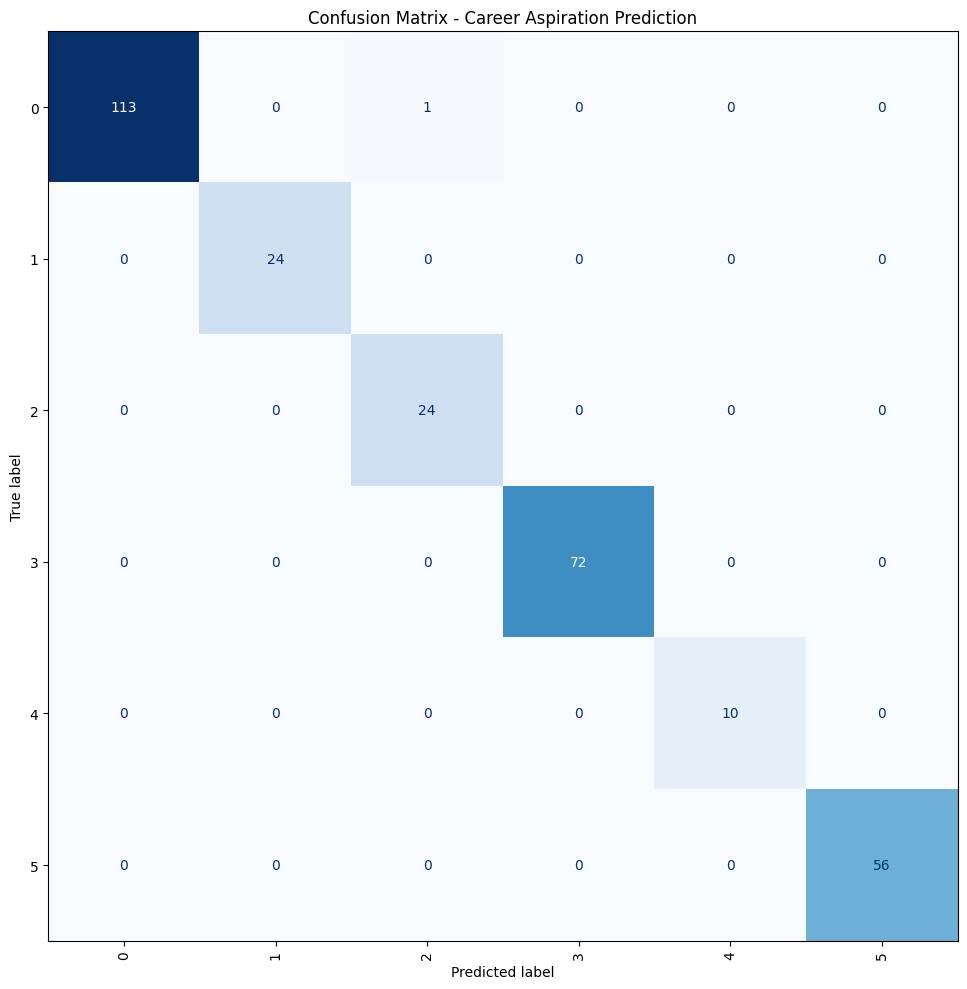

In [25]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

labels_present = np.unique(np.concatenate([y_test, y_pred]))
target_names_present = [class_names[i] for i in labels_present]

print(classification_report(
    y_test,
    y_pred,
    labels=labels_present,
    target_names=target_names_present,
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=labels_present)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names_present)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix - Career Aspiration Prediction")
plt.tight_layout()
plt.show()

## 17. Plot Accuracy dan Loss

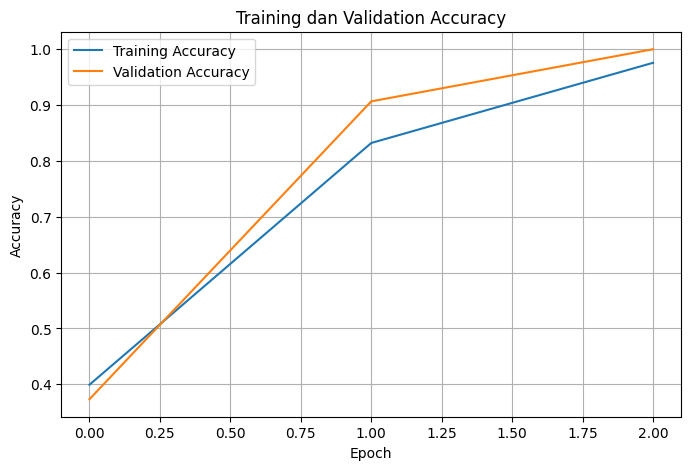

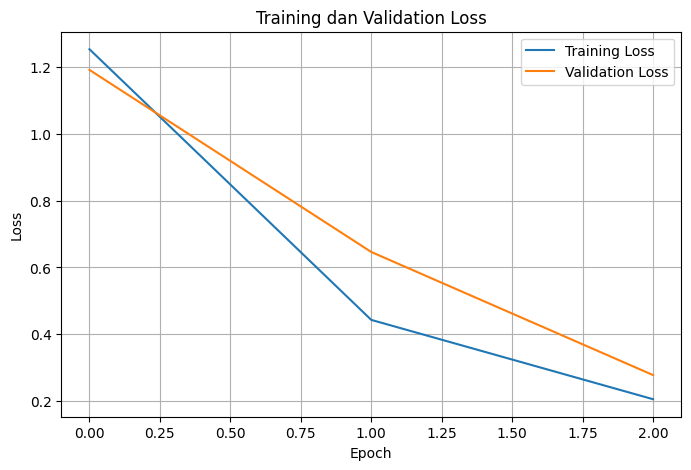

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 18. Simpan Model ke Format `.keras`

In [27]:
keras_model_path = "model_output/student_career_recommendation.keras"
model.save(keras_model_path)

print("Model berhasil disimpan ke format .keras:")
print(keras_model_path)

Model berhasil disimpan ke format .keras:
model_output/student_career_recommendation.keras


## 19. Export Model ke Format SavedModel

In [28]:
saved_model_path = "model_output/student_career_recommendation_savedmodel"

if os.path.exists(saved_model_path):
    shutil.rmtree(saved_model_path)

try:
    model.export(saved_model_path)
except AttributeError:
    tf.saved_model.save(model, saved_model_path)

print("Model berhasil diekspor ke format SavedModel:")
print(saved_model_path)

Saved artifact at 'model_output/student_career_recommendation_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 45), dtype=tf.float32, name='student_features')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  136265619756368: TensorSpec(shape=(1, 45), dtype=tf.float32, name=None)
  136265619754640: TensorSpec(shape=(1, 45), dtype=tf.float32, name=None)
  136265619767120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619754448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619755600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619754256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619753872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619765776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619753488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136265619754832: TensorSpec(shape=(), dtype=

In [29]:
!find model_output/student_career_recommendation_savedmodel -maxdepth 3 -type f

model_output/student_career_recommendation_savedmodel/saved_model.pb
model_output/student_career_recommendation_savedmodel/fingerprint.pb
model_output/student_career_recommendation_savedmodel/variables/variables.index
model_output/student_career_recommendation_savedmodel/variables/variables.data-00000-of-00001


## 20. Simpan Metadata Preprocessing

Metadata ini penting agar urutan fitur dan label saat inference sama dengan saat training.

In [30]:
metadata = {
    "feature_cols": feature_cols,
    "class_names": class_names,
    "feature_medians": {str(k): float(v) for k, v in feature_medians.to_dict().items()},
    "target_column": TARGET_COL,
    "input_dim": int(input_dim),
    "num_classes": int(num_classes)
}

with open("model_output/inference_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

joblib.dump(feature_medians, "model_output/feature_medians.joblib")
joblib.dump(label_encoder, "model_output/label_encoder.joblib")

print("Metadata inference berhasil disimpan.")

Metadata inference berhasil disimpan.


## 21. Inference Sederhana Menggunakan Data Test

In [31]:
sample_index = 0

sample_features = X_test[[sample_index]].astype("float32")
true_label = int(y_test[sample_index])

prediction_prob = model.predict(sample_features)
predicted_class = int(np.argmax(prediction_prob[0]))
confidence = float(np.max(prediction_prob[0]) * 100)

print("True Label      :", class_names[true_label])
print("Predicted Label :", class_names[predicted_class])
print("Confidence      : {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
True Label      : 3
Predicted Label : 3
Confidence      : 90.62%


## 22. Fungsi Inference untuk Input Baru

In [32]:
# ============================================================
# FIX INFERENCE: Samakan jumlah fitur input dengan model
# ============================================================

expected_dim = model.input_shape[-1]

print("Jumlah fitur yang diharapkan model:", expected_dim)
print("Jumlah fitur pada feature_cols saat ini:", len(feature_cols))

# Pastikan feature_cols yang dipakai sesuai dengan input model
if len(feature_cols) != expected_dim:
    print("PERINGATAN: Jumlah feature_cols tidak sama dengan input model.")
    print("feature_cols akan disesuaikan dengan jumlah fitur model.")
    feature_cols_inference = feature_cols[:expected_dim]
else:
    feature_cols_inference = feature_cols.copy()

print("Jumlah fitur untuk inference:", len(feature_cols_inference))
print(feature_cols_inference)

Jumlah fitur yang diharapkan model: 45
Jumlah fitur pada feature_cols saat ini: 45
Jumlah fitur untuk inference: 45
['part_time_job', 'absence_days', 'extracurricular_activities', 'weekly_self_study_hours', 'math_score', 'history_score', 'physics_score', 'chemistry_score', 'biology_score', 'english_score', 'geography_score', 'average_score', 'sains_score', 'sosial_score', 'bahasa_score', 'gender_female', 'gender_male', 'gender_Female', 'gender_Male', 'career_aspiration_Accountant', 'career_aspiration_Artist', 'career_aspiration_Banker', 'career_aspiration_Business Owner', 'career_aspiration_Construction Engineer', 'career_aspiration_Designer', 'career_aspiration_Doctor', 'career_aspiration_Game Developer', 'career_aspiration_Government Officer', 'career_aspiration_Lawyer', 'career_aspiration_Real Estate Developer', 'career_aspiration_Scientist', 'career_aspiration_Social Network Studies', 'career_aspiration_Software Engineer', 'career_aspiration_Stock Investor', 'career_aspiration_Teac

## 23. Load Model `.keras` dan Inference Ulang

Bagian ini membuktikan bahwa model tersimpan dapat dimuat kembali.

In [33]:
loaded_model = tf.keras.models.load_model(
    keras_model_path,
    custom_objects={"FeatureInteractionLayer": FeatureInteractionLayer}
)

loaded_prediction = loaded_model.predict(X_test[[0]].astype("float32"))
loaded_predicted_class = int(np.argmax(loaded_prediction[0]))

print("Prediksi dari model yang di-load ulang:")
print("Predicted Label:", class_names[loaded_predicted_class])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'custom_feature_interaction', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Prediksi dari model yang di-load ulang:
Predicted Label: 3


## 24. Membuat `requirements.txt`

In [34]:
requirements = """tensorflow
pandas
numpy
scikit-learn
matplotlib
joblib
"""

with open("model_output/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt berhasil dibuat di model_output/requirements.txt")

requirements.txt berhasil dibuat di model_output/requirements.txt
